# Notebook 06 — Validación final: hipervolumen sobre ZCAT1–ZCAT20

## Objetivo

Responder a la pregunta de investigación central del TFM:

> **¿La configuración de NSGA-II obtenida mediante la optimización de hiperparámetros
> produce frentes de Pareto de mayor calidad (medida en hipervolumen) que la
> configuración base, sobre el conjunto completo de problemas ZCAT1–ZCAT20?**

## 1. Introducción

Se comparan dos configuraciones de NSGA-II:

- **Base**: la configuración de partida del TFM (pop=100, SBX, mutación polinómica,
  reparación `clamp`, sin archivo externo).
- **Optimizada**: la configuración recomendada por el análisis de hiperparámetros del
  Notebook 05 (pop_size=52, offspring_ratio=0.25, initializer `obl`, SBX con
  prob≈0.8382/eta≈18.3810, mutación `linked_polynomial` con prob_factor≈1.3022/
  eta≈21.8997, selección `tournament` con tamaño 6, reparación `reflect`, archivo
  externo ilimitado con poda por hipervolumen).

Ambas se ejecutan sobre los **20 problemas de la familia ZCAT (ZCAT1–ZCAT20)**, y se
calcula el hipervolumen final de cada ejecución, además de curvas de convergencia de HV
para un subconjunto representativo de problemas.

## 2. Imports y configuración general

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vamos import optimize
from vamos.algorithms import NSGAIIConfig
from vamos.foundation.quality_indicators import compute_hypervolume
from vamos.ux.api import result_to_latex

SEED = 42
ENGINE = "numpy"

plt.rcParams["figure.dpi"] = 110


## 3. Configuraciones a comparar

In [2]:
base_config = (
    NSGAIIConfig.builder()
    .pop_size(100)
    .crossover("sbx", prob=0.9, eta=20.0)
    .mutation("pm", prob="1/n", eta=20.0)
    .selection("tournament", size=2)
    .repair("clamp")
    .build()
)

optimized_config = (
    NSGAIIConfig.builder()
    .pop_size(52)
    .offspring_size(round(52 * 0.25))  # offspring_ratio = 0.25
    .initializer("obl")
    .crossover("sbx", prob=0.8382, eta=18.3810)
    .mutation("linked_polynomial", prob="1.3022/n", eta=21.8997)
    .selection("tournament", size=6)  # selection_size = 6
    .repair("reflect")
    .external_archive(
        capacity=None,
        pruning="hv",
    )
    .build()
)

CONFIGS = {
    "base": base_config,
    "optimizada": optimized_config,
}


## 4. Problemas de benchmark: ZCAT1–ZCAT20

Se usan los 20 problemas de la familia ZCAT.

In [3]:
PROBLEM_KEYS = [f"zcat{i}" for i in range(1, 21)]
assert len(PROBLEM_KEYS) == 20

# Subconjunto representativo para las curvas de convergencia y los frentes 2D
REPRESENTATIVE = ["zcat1", "zcat10", "zcat20"]

MAX_EVALUATIONS = 15000
POP_SIZE = 100  # pop_size de referencia para las llamadas que no usan algorithm_config
CHECKPOINT_FRACTIONS = [0.25, 0.50, 0.75, 1.00]


## 5. Ejecución con checkpoints y cálculo de hipervolumen

Para cada problema y cada configuración se ejecuta `optimize(...)` con presupuestos
crecientes (25/50/75/100 % de `MAX_EVALUATIONS`) manteniendo el mismo `seed`, para poder
trazar la evolución del HV a lo largo de la optimización.

El punto de referencia del hipervolumen se calcula **por problema**, compartido entre
ambas configuraciones y todos los checkpoints, como `1.1 * max` de los objetivos
observados en todas las ejecuciones de ese problema — así el HV es comparable entre
configuraciones.

In [4]:
def run_checkpoints(problem_key, algorithm_config, seed=SEED, engine=ENGINE):
    """Ejecuta optimize() en presupuestos crecientes. Devuelve {fraccion: result}."""
    checkpoints = {}
    for frac in CHECKPOINT_FRACTIONS:
        budget = max(1, int(MAX_EVALUATIONS * frac))
        result = optimize(
            problem_key,
            algorithm="nsgaii",
            algorithm_config=algorithm_config,
            termination=("max_evaluations", budget),
            seed=seed,
            engine=engine,
        )
        checkpoints[frac] = result
    return checkpoints


all_checkpoints = {}  # {(problem_key, config_name): {frac: result}}
records = []

for problem_key in PROBLEM_KEYS:
    per_problem_results = {}
    for config_name, cfg in CONFIGS.items():
        start = time.perf_counter()
        checkpoints = run_checkpoints(problem_key, cfg)
        elapsed = time.perf_counter() - start
        all_checkpoints[(problem_key, config_name)] = checkpoints
        per_problem_results[config_name] = checkpoints
        records.append({"problem": problem_key, "config": config_name, "runtime_s": elapsed})

    # Punto de referencia compartido para este problema (todas las configs y checkpoints)
    all_F = [
        checkpoints[frac].F
        for checkpoints in per_problem_results.values()
        for frac in CHECKPOINT_FRACTIONS
    ]
    ref_point = 1.1 * np.vstack(all_F).max(axis=0)

    for config_name, checkpoints in per_problem_results.items():
        for frac in CHECKPOINT_FRACTIONS:
            hv = compute_hypervolume(checkpoints[frac].F, ref_point)
            records.append(
                {
                    "problem": problem_key,
                    "config": config_name,
                    "fraction": frac,
                    "hv": hv,
                    "n_solutions": len(checkpoints[frac]),
                }
            )

results_df = pd.DataFrame.from_records(records)
results_df = results_df.dropna(subset=["fraction"])  # descarta las filas de solo runtime
results_df


,problem,config,runtime_s,fraction,hv,n_solutions
2,zcat1,base,NaN,0.25,2.976004,100.0
3,zcat1,base,NaN,0.50,3.227318,100.0
4,zcat1,base,NaN,0.75,3.252493,100.0
5,zcat1,base,NaN,1.00,3.259967,100.0
6,zcat1,optimizada,NaN,0.25,3.182808,161.0
...,...,...,...,...,...,...
195,zcat20,base,NaN,1.00,3.717694,100.0
196,zcat20,optimizada,NaN,0.25,3.687005,190.0
197,zcat20,optimizada,NaN,0.50,3.728279,340.0
198,zcat20,optimizada,NaN,0.75,3.739645,658.0


## 6. Resultados finales (100 % del presupuesto): base vs. optimizada

In [ ]:
final_df = results_df[results_df["fraction"] == 1.00].reset_index(drop=True)
final_df

,problem,config,runtime_s,fraction,hv,n_solutions
0,zcat1,base,NaN,1.0,3.259967,100.0
1,zcat1,optimizada,NaN,1.0,3.295652,986.0
2,zcat2,base,NaN,1.0,4.052902,100.0
3,zcat2,optimizada,NaN,1.0,4.079635,837.0
4,zcat3,base,NaN,1.0,3.345792,100.0
5,zcat3,optimizada,NaN,1.0,3.377018,799.0
6,zcat4,base,NaN,1.0,3.345792,100.0
7,zcat4,optimizada,NaN,1.0,3.377018,799.0
8,zcat5,base,NaN,1.0,4.370574,100.0
9,zcat5,optimizada,NaN,1.0,4.391317,849.0


In [6]:
summary = final_df.groupby("config")["hv"].agg(["mean", "std", "min", "max"])
summary


,mean,std,min,max
config,,,,
base,3.312360,0.691140,1.703516,4.370574
optimizada,3.302524,0.693664,1.719416,4.391317


In [7]:
from scipy.stats import wilcoxon

pivot = final_df.pivot(index="problem", columns="config", values="hv").sort_index()
stat, p_value = wilcoxon(pivot["optimizada"], pivot["base"])

print(f"Wilcoxon (HV optimizada vs. base): estadístico={stat:.4f}, p-valor={p_value:.4g}")
print("Diferencia media de HV (optimizada - base):", (pivot["optimizada"] - pivot["base"]).mean())
print("Nº de problemas donde optimizada >= base:", (pivot["optimizada"] >= pivot["base"]).sum(), "/", len(pivot))


Wilcoxon (HV optimizada vs. base): estadístico=39.0000, p-valor=0.01369
Diferencia media de HV (optimizada - base): -0.009836686970453923
Nº de problemas donde optimizada >= base: 18 / 20


## 7. Comparación de HV final por problema (ZCAT1–ZCAT20)

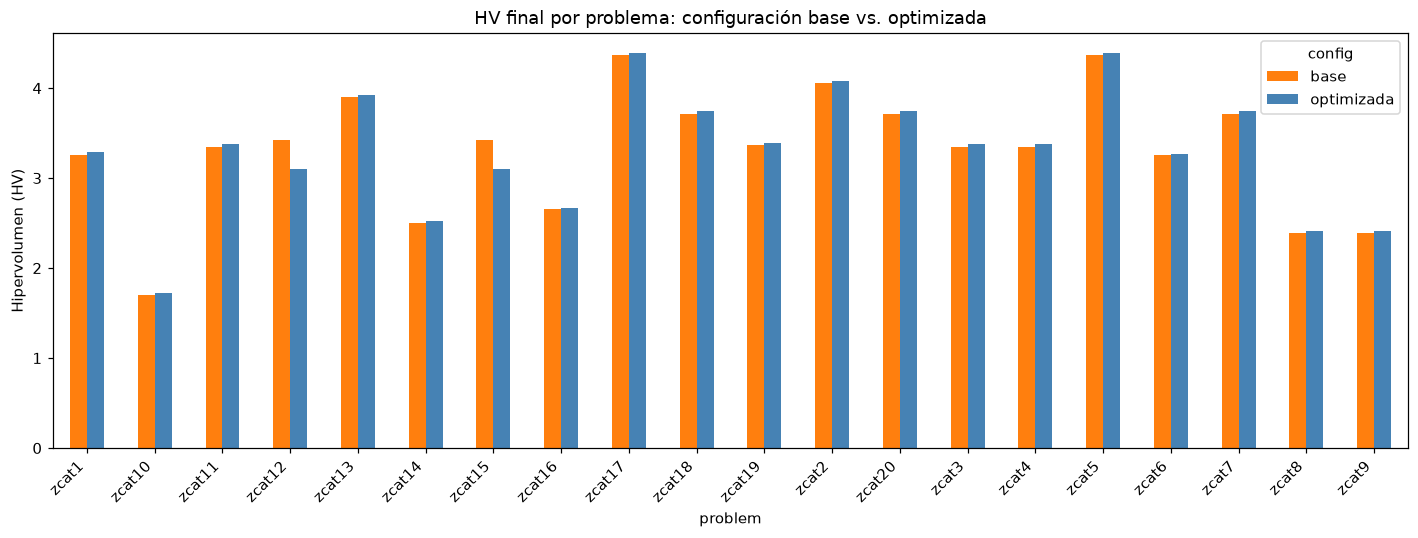

In [8]:
ax = pivot.plot(kind="bar", figsize=(13, 5), color=["tab:orange", "steelblue"])
ax.set_ylabel("Hipervolumen (HV)")
ax.set_title("HV final por problema: configuración base vs. optimizada")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 8. Curvas de convergencia de HV

Evolución del hipervolumen a lo largo del presupuesto de evaluaciones (checkpoints al
25/50/75/100 %), para los problemas representativos.

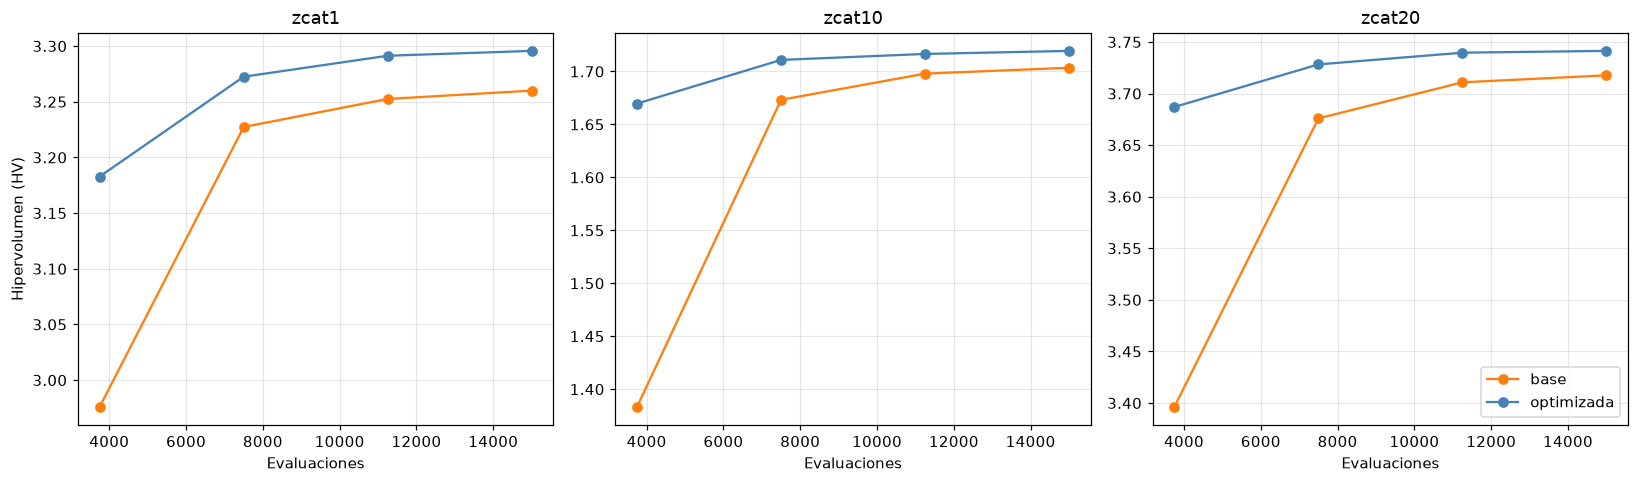

In [9]:
fig, axes = plt.subplots(1, len(REPRESENTATIVE), figsize=(5 * len(REPRESENTATIVE), 4.5), sharey=False)
if len(REPRESENTATIVE) == 1:
    axes = [axes]

for ax, problem_key in zip(axes, REPRESENTATIVE):
    sub = results_df[results_df["problem"] == problem_key].sort_values("fraction")
    for config_name, color in zip(CONFIGS.keys(), ["tab:orange", "steelblue"]):
        sub_cfg = sub[sub["config"] == config_name]
        evaluations = sub_cfg["fraction"] * MAX_EVALUATIONS
        ax.plot(evaluations, sub_cfg["hv"], marker="o", color=color, label=config_name)

    ax.set_title(problem_key)
    ax.set_xlabel("Evaluaciones")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Hipervolumen (HV)")
axes[-1].legend(loc="best")
plt.tight_layout()
plt.show()


## 9. Frentes finales (2D): base vs. optimizada

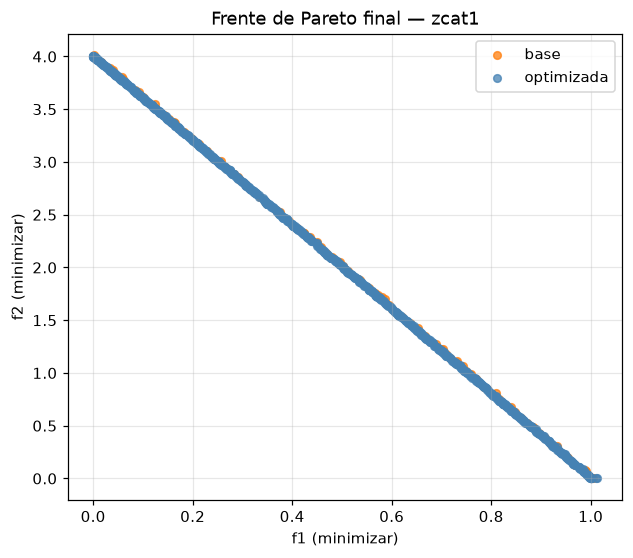

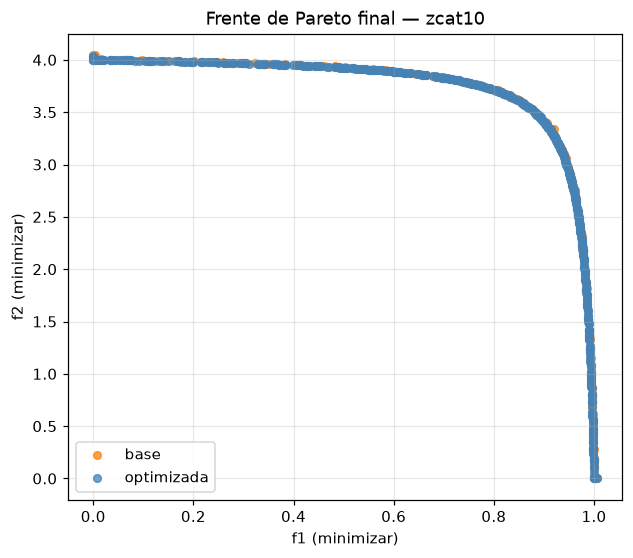

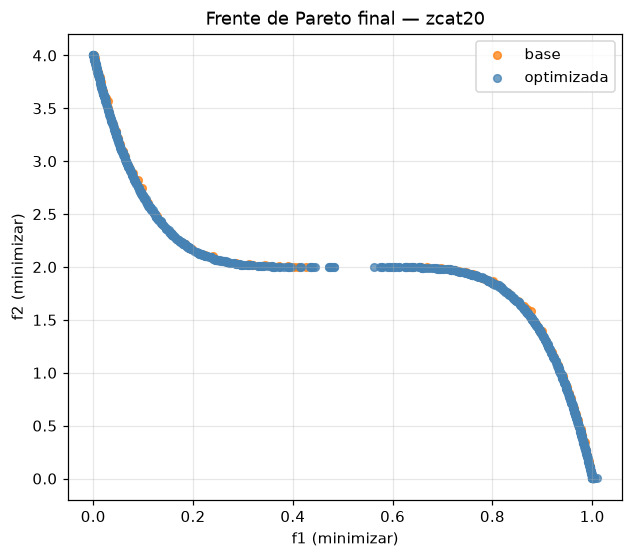

In [10]:
for problem_key in REPRESENTATIVE:
    plt.figure(figsize=(6.5, 5.5))
    for config_name, color in zip(CONFIGS.keys(), ["tab:orange", "steelblue"]):
        F = all_checkpoints[(problem_key, config_name)][1.00].F
        plt.scatter(F[:, 0], F[:, 1], s=25, alpha=0.75, color=color, label=config_name)

    plt.title(f"Frente de Pareto final — {problem_key}")
    plt.xlabel("f1 (minimizar)")
    plt.ylabel("f2 (minimizar)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
